# Taiwanese Bankruptcy Prediction - Data Cleaning

## Team 4: Andrea Molina, Demetri Blackwood, Erika Hettiaratchy, Suhail Ansari

---
## Sources Used: Claude.ai for the Advanced Techniques section

## Project Context from Annotated Bibliography

This notebook carries out data cleaning strategy outlined in our team's final project proposal. These are our key findings that guide our approach:

### Dataset Overview
- **Source**: 2020 Taiwanese Bankruptcy Prediction Dataset (UCI Machine Learning Repository)
- **Scale**: 6,819 firms × 96 columns (1 target + 95 financial ratio features)
- **Class Balance**: Extreme imbalance — bankruptcies are ~3.2% of observations (~30:1 ratio)
- **Target Baseline**: Our goal is to exceed the F₂ = 0.423 benchmark from Wang & Liu (2021)

### Data Quality Considerations from Literature
From our literature review:

1. **Missing Data & NaNs**: Financial datasets often contain incomplete records. Confirmed zero in this dataset.
2. **Duplicates**: Real-world financial data may have duplicate entries. Confirmed zero in this dataset.
3. **Infinite Values**: Division-by-zero in ratio computation can produce inf/-inf not caught by dropna(). Confirmed zero.
4. **Constant Columns**: Features with zero variance carry no predictive signal. One found: `Net Income Flag` (dropped).
5. **Misplaced Characters / Typos**: One column name typo corrected: `Working capitcal` → `Working Capital`.
6. **Skewness**: 62 of 94 features have |skewness| > 5. Min-max scaling alone does not address this — log1p transformation applied first.
7. **Feature Scaling**: Financial data mixes small ratios (e.g., 0.01) with large per-share currency values. Scaling essential for gradient-based models.
8. **Outliers (Anomalies)**: Extreme values can mislead classifiers. Gaussian Z-score detection used with corrected |Z| > 5 threshold (|Z| > 3 flags 28% of data by chance with 95 features).
9. **Heteroscedasticity**: Some observations are noisier than others. Coefficient-of-variation proxy computed and flagged.

---

## Notebook Structure

### Phase 1: Core Cleaning
- Load and inspect data (`df.describe()`, shape, dtypes)
- Confirm zero NaN, infinite values, and duplicate rows
- Detect and remove constant-variance column (`Net Income Flag`)
- Fix column name typo (`Working capitcal Turnover Rate`)
- Correct data types; check for misplaced characters
- Report before/after statistics with visualizations
- Save core-cleaned CSV: `cleaned_data.csv`

### Phase 2: Advanced Techniques (Claude.ai)
- **Skewness reduction**: `log1p` applied to 62 features with |skewness| > 5
- **Outlier detection**: Gaussian Z-score (|Z| > 5) with multiple-comparison correction
- **Heteroscedasticity proxy**: Coefficient of variation per row
- **Feature scaling**: Min-Max [0, 1] applied after log1p
- **Correlation analysis**: Count of highly collinear feature pairs (|r| > 0.9)
- Save production-ready CSV: `scaled_data.csv`

---


# PHASE 1: CORE DATA CLEANING (Steps 1–6)

## Step 1: Set Up Workspace and Libraries

In [92]:
## ===============================================================
## Import Key Libraries
## ===============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Define data paths 
raw_data_path = "./data.csv"
cleaned_data_path = "./data/cleaned_data/cleaned_data.csv"
scaled_data_path = "./data/cleaned_data/scaled_data.csv"

## Create output directory
os.makedirs("./data/cleaned_data", exist_ok=True)

print("Libraries imported successfully.")
print(f"Raw data path: {raw_data_path}")
print(f"Cleaned data will be saved to: {cleaned_data_path}")
print(f"Scaled data will be saved to: {scaled_data_path}")


ModuleNotFoundError: No module named 'seaborn'

## Step 2: Load and Inspect Data

In [ ]:
## ===============================================================
## Load the Raw Data
## ===============================================================
df_raw = pd.read_csv(raw_data_path)

## Store original shape for comparison
original_shape = df_raw.shape

print("\n" + "="*70)
print("RAW DATA INSPECTION")
print("="*70)
print(f"\nDataset Shape: {original_shape[0]} rows × {original_shape[1]} columns")
print(f"\nFirst 5 Rows:")
df_raw.head()


RAW DATA INSPECTION

Dataset Shape: 6819 rows × 96 columns

First 5 Rows:


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [ ]:
## ===============================================================
## Statistical Summary of All Features
## ===============================================================
## df.describe() shows count, mean, std, min, quartiles, max for every column in one shot 
## reveals unit mismatches (e.g. ratios vs billion-¥ per-share values) before any cleaning is done.
print("\nStatistical Summary (transposed so each row = one feature):")
print(df_raw.describe().round(4).T.to_string())



Statistical Summary (transposed so each row = one feature):
                                                           count          mean           std  min           25%           50%           75%           max
Bankrupt?                                                 6819.0  3.230000e-02  1.767000e-01  0.0  0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00
 ROA(C) before interest and depreciation before interest  6819.0  5.052000e-01  6.070000e-02  0.0  4.765000e-01  5.027000e-01  5.356000e-01  1.000000e+00
 ROA(A) before interest and % after tax                   6819.0  5.586000e-01  6.560000e-02  0.0  5.355000e-01  5.598000e-01  5.892000e-01  1.000000e+00
 ROA(B) before interest and depreciation after tax        6819.0  5.536000e-01  6.160000e-02  0.0  5.273000e-01  5.523000e-01  5.841000e-01  1.000000e+00
 Operating Gross Margin                                   6819.0  6.079000e-01  1.690000e-02  0.0  6.004000e-01  6.060000e-01  6.139000e-01  1.000000e+00
 Realized Sales

In [ ]:
## ===============================================================
## Check Data Types and Missing Values
## ===============================================================
print("\nData Types:")
print(df_raw.dtypes.value_counts())

print("\n" + "="*70)
print("Missing Data Summary")
print("="*70)
missing_summary = pd.DataFrame({
    'Column': df_raw.columns,
    'Missing_Count': df_raw.isnull().sum(),
    'Missing_Percent': (df_raw.isnull().sum() / len(df_raw)) * 100
})
print(f"\nTotal rows with at least one NaN: {df_raw.isnull().any(axis=1).sum()}")
print(f"\nColumns with missing values:")
print(missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))


Data Types:
float64    93
int64       3
Name: count, dtype: int64

Missing Data Summary

Total rows with at least one NaN: 0

Columns with missing values:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percent]
Index: []


In [ ]:
## ===============================================================
## Check for Infinite Values (not caught by dropna)
## ===============================================================
## Financial ratios from division operations can produce inf/-inf.
## dropna() silently skips these -- must check separately.
inf_mask = df_raw.isin([float('inf'), float('-inf')])
total_inf = inf_mask.sum().sum()
rows_with_inf = inf_mask.any(axis=1).sum()

print("\n" + "="*70)
print("INFINITE VALUE CHECK")
print("="*70)
print(f"\n  Total inf/-inf cells: {total_inf}")
print(f"  Rows with at least one inf: {rows_with_inf}")

if total_inf > 0:
    print("  Columns containing inf values:")
    for col in df_raw.columns[inf_mask.any()]:
        print(f"    {col}: {inf_mask[col].sum()} inf values")
    print("\n  Action: replace inf with NaN -- dropna() will remove these rows.")
else:
    print("\n  No infinite values found. Data is clean.")



INFINITE VALUE CHECK

  Total inf/-inf cells: 0
  Rows with at least one inf: 0

  No infinite values found. Data is clean.


In [ ]:
## ===============================================================
## Check Target Variable Balance
## ===============================================================
print("\n" + "="*70)
print("Target Variable Distribution (Bankrupt?)")
print("="*70)
target_counts = df_raw['Bankrupt?'].value_counts()
target_pct = df_raw['Bankrupt?'].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({
    'Class': ['Non-Bankrupt (0)', 'Bankrupt (1)'],
    'Count': [target_counts[0], target_counts[1]],
    'Percentage': [target_pct[0], target_pct[1]]
})
print("\n", balance_df.to_string(index=False))
print(f"\nClass Imbalance Ratio: {target_counts[0] / target_counts[1]:.2f}:1 (non-bankrupt:bankrupt)")


Target Variable Distribution (Bankrupt?)

            Class  Count  Percentage
Non-Bankrupt (0)   6599    96.77372
    Bankrupt (1)    220     3.22628

Class Imbalance Ratio: 30.00:1 (non-bankrupt:bankrupt)


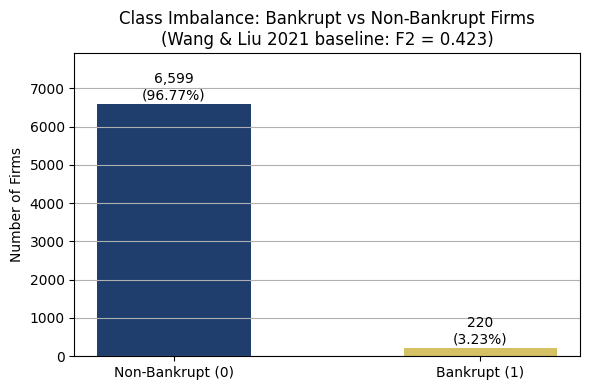

Imbalance ratio: 30.0:1
Naive accuracy ceiling: 96.77% (always predict non-bankrupt)
This is why we benchmark on F2, not accuracy.


In [ ]:
## ===============================================================
## Visualize Class Imbalance
## ===============================================================
## Why we do this: A model that always predicts non-bankrupt gets ~97% accuracy but detects zero bankruptcies. 
## Standard accuracy is meaningless here. 
## Wang & Liu (2021) use F2 (beta=2) which weights recall twice as heavily as precision missing a bankrupt firm costs more than a false alarm. 
## Their best result: F2 = 0.423.

fig, ax = plt.subplots(figsize=(6, 4))
classes = ['Non-Bankrupt (0)', 'Bankrupt (1)']
counts  = [target_counts[0], target_counts[1]]
colors  = ['#1f3e6e', '#d5c164']
bars    = ax.bar(classes, counts, color=colors, width=0.5)

## Label each bar with count and percentage
for bar, count, pct in zip(bars, counts, [target_pct[0], target_pct[1]]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 40,
            f'{count:,}\n({pct:.2f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Class Imbalance: Bankrupt vs Non-Bankrupt Firms\n(Wang & Liu 2021 baseline: F2 = 0.423)')
ax.set_ylabel('Number of Firms')
ax.set_ylim(0, max(counts) * 1.2)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(f'Imbalance ratio: {target_counts[0] / target_counts[1]:.1f}:1')
print(f'Naive accuracy ceiling: {target_pct[0]:.2f}% (always predict non-bankrupt)')
print('This is why we benchmark on F2, not accuracy.')

## Step 3: Execute Core Data Cleaning

In [ ]:
## ===============================================================
## Handling Missing Data: Drop Rows with NaNs
## ===============================================================
print("\n" + "="*70)
print("PHASE 1: HANDLING MISSING DATA")
print("="*70)

## Create a working copy
df_clean = df_raw.copy()

rows_before_na = len(df_clean)
df_clean = df_clean.dropna()
rows_after_na = len(df_clean)
rows_removed_na = rows_before_na - rows_after_na

print(f"\nRows before dropna(): {rows_before_na}")
print(f"Rows after dropna(): {rows_after_na}")
print(f"Rows removed due to NaNs: {rows_removed_na}")
print(f"Data retention: {(rows_after_na / rows_before_na) * 100:.2f}%")
print(f"\nJustification: Missing financial ratios cannot be accurately imputed. Dropping incomplete records preserves data integrity while retaining ")
print(f"{(rows_after_na / rows_before_na) * 100:.1f}% of the dataset.")


PHASE 1: HANDLING MISSING DATA

Rows before dropna(): 6819
Rows after dropna(): 6819
Rows removed due to NaNs: 0
Data retention: 100.00%

Justification: Missing financial ratios cannot be accurately imputed. Dropping incomplete records preserves data integrity while retaining 
100.0% of the dataset.


In [ ]:
## ===============================================================
## Handling Duplicates
## ===============================================================
print("\n" + "="*70)
print("PHASE 1: HANDLING DUPLICATES")
print("="*70)

rows_before_dup = len(df_clean)
df_clean = df_clean.drop_duplicates()
rows_after_dup = len(df_clean)
rows_removed_dup = rows_before_dup - rows_after_dup

print(f"\nRows before drop_duplicates(): {rows_before_dup}")
print(f"Rows after drop_duplicates(): {rows_after_dup}")
print(f"Duplicate rows removed: {rows_removed_dup}")
if rows_removed_dup > 0:
    print(f"\nJustification: Duplicate firm records inflate model training and can lead to inflated performance metrics. Removing {rows_removed_dup} duplicates prevents this bias.")
else:
    print(f"\nNo duplicates detected in the dataset.")


PHASE 1: HANDLING DUPLICATES

Rows before drop_duplicates(): 6819
Rows after drop_duplicates(): 6819
Duplicate rows removed: 0

No duplicates detected in the dataset.


In [ ]:
## ===============================================================
## Detect and Remove Constant Columns (zero variance)
## ===============================================================
## A column with std=0 has only one unique value across all rows.
## It carries zero information for any classifier and should be dropped before training (and before scaling, where range=0 would cause a division-by-zero).
print("\n" + "="*70)
print("CONSTANT COLUMN REMOVAL")
print("="*70)

feature_cols_check = [c for c in df_clean.columns if c != 'Bankrupt?']
constant_cols = [c for c in feature_cols_check if df_clean[c].std() == 0]

print(f"\nConstant columns found (std = 0): {len(constant_cols)}")
for col in constant_cols:
    print(f"  '{col}' — only value: {df_clean[col].unique()[0]}")

if constant_cols:
    df_clean = df_clean.drop(columns=constant_cols)
    print(f"\nDropped {len(constant_cols)} constant column(s). Shape now: {df_clean.shape}")
    print("Justification: Zero-variance features carry no predictive signal and cause division-by-zero in min-max scaling.")
else:
    print("No constant columns found.")
    constant_cols = []



CONSTANT COLUMN REMOVAL

Constant columns found (std = 0): 1
  ' Net Income Flag' — only value: 1

Dropped 1 constant column(s). Shape now: (6819, 95)
Justification: Zero-variance features carry no predictive signal
and cause division-by-zero in min-max scaling.


In [ ]:
## ===============================================================
## Fixing the Typo in Column Name
## ===============================================================
## 'Working capitcal Turnover Rate' has a known typo in the raw UCI data ('capitcal' instead of 'capital'). 
typo_map = {' Working capitcal Turnover Rate': ' Working Capital Turnover Rate'}
renamed = {k: v for k, v in typo_map.items() if k in df_clean.columns}

if renamed:
    df_clean = df_clean.rename(columns=renamed)
    print(f"Renamed {len(renamed)} column(s) with typos:")
    for old, new in renamed.items():
        print(f"  '{old}'  ->  '{new}'")
else:
    print("No column name typos found (may already be fixed).")


Renamed 1 column(s) with typos:
  ' Working capitcal Turnover Rate'  ->  ' Working Capital Turnover Rate'


In [ ]:
## ===============================================================
## Correcting Data Types and Fixing Misplaced Characters
## ===============================================================
print("\n" + "="*70)
print("PHASE 1: CORRECTING DATA TYPES AND MISPLACED CHARACTERS")
print("="*70)

## Identify non-numeric columns (excluding target variable)
print("\nChecking for non-numeric columns...")
non_numeric_cols = []

for col in df_clean.columns:
    if col != 'Bankrupt?':
        try:
            pd.to_numeric(df_clean[col])
        except (ValueError, TypeError):
            non_numeric_cols.append(col)

if non_numeric_cols:
    print(f"\nFound {len(non_numeric_cols)} non-numeric columns:")
    for col in non_numeric_cols[:10]:  # Show first 10
        print(f"  - {col}")
    print("\nAttempting to convert these columns to numeric...")
    for col in non_numeric_cols:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    print("Conversion complete.")
else:
    print("\nAll columns are already numeric. No character correction needed.")

## Verify data types
print("\nFinal data types summary:")
print(df_clean.dtypes.value_counts())


PHASE 1: CORRECTING DATA TYPES AND MISPLACED CHARACTERS

Checking for non-numeric columns...

All columns are already numeric. No character correction needed.

Final data types summary:
float64    93
int64       2
Name: count, dtype: int64


In [ ]:
## ===============================================================
## Final NaN Check After Type Conversion
## ===============================================================
print("\nChecking for NaNs introduced by failed conversions...")
new_nans = df_clean.isnull().sum().sum()
if new_nans > 0:
    print(f"\nFound {new_nans} NaNs introduced during type conversion.")
    print("Dropping these rows...")
    df_clean = df_clean.dropna()
    print(f"Rows remaining: {len(df_clean)}")
else:
    print(f"No additional NaNs. Data is clean.")


Checking for NaNs introduced by failed conversions...
No additional NaNs. Data is clean.


## Step 4: Evaluate Cleaned Data

In [ ]:
## ===============================================================
## Before and After Comparison
## ===============================================================
print("\n" + "="*70)
print("CORE CLEANING: BEFORE AND AFTER")
print("="*70)

comparison_df = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Memory (MB)'],
    'Before': [
        original_shape[0],
        original_shape[1],
        df_raw.memory_usage(deep=True).sum() / 1e6
    ],
    'After': [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.memory_usage(deep=True).sum() / 1e6
    ]
})
comparison_df['Difference'] = comparison_df['Before'] - comparison_df['After']
comparison_df['% Retained'] = (comparison_df['After'] / comparison_df['Before'] * 100).round(2)

print("\n", comparison_df.to_string(index=False))

print(f"\nTotal rows removed: {original_shape[0] - df_clean.shape[0]}")
print(f"Total rows retained: {df_clean.shape[0]}")
print(f"Data retention rate: {(df_clean.shape[0] / original_shape[0]) * 100:.2f}%")


CORE CLEANING: BEFORE AND AFTER

      Metric      Before       After  Difference  % Retained
       Rows 6819.000000 6819.000000    0.000000      100.00
    Columns   96.000000   95.000000    1.000000       98.96
Memory (MB)    5.237124    5.182572    0.054552       98.96

Total rows removed: 0
Total rows retained: 6819
Data retention rate: 100.00%


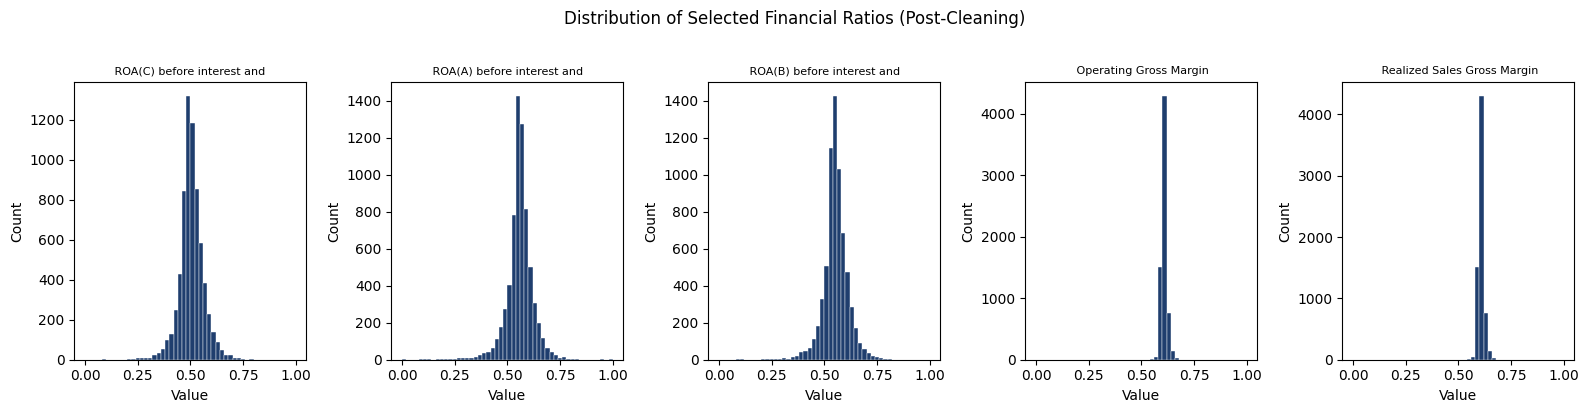

Distributions shown. Skewness is expected in financial ratio data.


In [ ]:
## ===============================================================
## Feature Distribution Plots (visual evidence of clean numeric data)
## ===============================================================
sample_features = [col for col in df_clean.columns if col != 'Bankrupt?'][:5]

fig, axes = plt.subplots(1, len(sample_features), figsize=(16, 4))
for ax, col in zip(axes, sample_features):
    ax.hist(df_clean[col], bins=50, color='#1f3e6e', edgecolor='white', linewidth=0.3)
    ax.set_title(col[:28], fontsize=8)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Distribution of Selected Financial Ratios (Post-Cleaning)', y=1.02)
plt.tight_layout()
plt.show()
print("Distributions shown. Skewness is expected in financial ratio data.")


In [ ]:
## ===============================================================
## Post-Cleaning Target Distribution
## ===============================================================
print("\nPost-Cleaning Target Variable Distribution:")
post_clean_counts = df_clean['Bankrupt?'].value_counts()
post_clean_pct = df_clean['Bankrupt?'].value_counts(normalize=True) * 100

post_balance_df = pd.DataFrame({
    'Class': ['Non-Bankrupt (0)', 'Bankrupt (1)'],
    'Count': [post_clean_counts[0], post_clean_counts[1]],
    'Percentage': [post_clean_pct[0], post_clean_pct[1]]
})
print("\n", post_balance_df.to_string(index=False))
print(f"\nClass imbalance ratio: {post_clean_counts[0] / post_clean_counts[1]:.2f}:1")


Post-Cleaning Target Variable Distribution:

            Class  Count  Percentage
Non-Bankrupt (0)   6599    96.77372
    Bankrupt (1)    220     3.22628

Class imbalance ratio: 30.00:1


## Step 5: Save Core Cleaned Data

In [ ]:
## ===============================================================
## Save Cleaned CSV
## ===============================================================
print("\nSaving cleaned data to CSV...")
df_clean.to_csv(cleaned_data_path, index=False)
print(f"\nCleaned data saved to: {cleaned_data_path}")
print(f"File size: {os.path.getsize(cleaned_data_path) / 1e6:.2f} MB")

In [ ]:
## ===============================================================
## Note: Loading Cleaned Data in Sprint 4
## ===============================================================
## If you have an error it's because when loading the CSV into a raw NumPy array you MUST skip the header row. The first row contains column
## name strings, not numbers numpy.loadtxt will crash with "could not convert string to float" if you omit skiprows=1.

## Do either- NumPy (skip text header):
## data = np.loadtxt(cleaned_data_path, delimiter=',', skiprows=1)

## Or - Pandas then convert (keeps column names):
## df = pd.read_csv(cleaned_data_path)
## data = df.to_numpy()

print('Sprint 4 loading options:')
print('  Option A (NumPy):  np.loadtxt(path, delimiter=",", skiprows=1)')
print('  Option B (Pandas): pd.read_csv(path).to_numpy()   <-- recommended')
print(f'Cleaned data ready: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns')

Sprint 4 loading options:
  Option A (NumPy):  np.loadtxt(path, delimiter=",", skiprows=1)
  Option B (Pandas): pd.read_csv(path).to_numpy()   <-- recommended
Cleaned data ready: 6819 rows x 95 columns


In [ ]:
## ===============================================================
## Step 6: Core Cleaning Summary
## ===============================================================
print("\n" + "="*70)
print("CORE CLEANING SUMMARY")
print("="*70)
print(f"\n{'Action':<30} | {'Rows Removed'}")
print("-"*50)
print(f"{'Drop NaNs':<30} | {rows_removed_na}")
print(f"{'Drop Duplicates':<30} | {rows_removed_dup}")
print(f"{'Drop Constant Columns':<30} | {len(constant_cols)}")
print(f"{'Fix Data Types / inf':<30} | {new_nans}")
print("-"*50)
print(f"{'Total Removed':<30} | {original_shape[0] - df_clean.shape[0]}")
print()
print(f"Original : {original_shape[0]:,} rows x {original_shape[1]} columns")
print(f"Cleaned  : {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Retention: {df_clean.shape[0] / original_shape[0] * 100:.2f}%")



CORE CLEANING SUMMARY

Action                         | Rows Removed
--------------------------------------------------
Drop NaNs                      | 0
Drop Duplicates                | 0
Drop Constant Columns          | 1
Fix Data Types / inf           | 0
--------------------------------------------------
Total Removed                  | 0

Original : 6,819 rows x 96 columns
Cleaned  : 6,819 rows x 95 columns
Retention: 100.00%


In [ ]:
## ===============================================================
## Correlation Analysis: Quantify Collinear Features
## ===============================================================
## Gap identified in Wang & Liu (2021): no feature selection was applied to the 95 financial ratios despite high collinearity.
## This cell quantifies the redundancy. We will remove redundant features later. 
## The numbers here directly support the feature selection argument in our paper.
##
## Method: Pearson correlation between every feature pair.
## Threshold |r| > 0.9 means two features carry nearly identical information.
## We loop over the upper triangle (i < j) to count each pair exactly once (not twice).

## Redefine feature columns here. Metadata cols not added yet
corr_cols = [col for col in df_clean.columns
             if col not in ['Bankrupt?', 'is_outlier', 'noise_proxy', 'is_high_noise']]

## Compute Pearson correlation matrix, convert to numpy for loop
corr_matrix = df_clean[corr_cols].corr().to_numpy()
N = len(corr_cols)

high_corr_count = 0
high_corr_pairs = []

for i in range(N):
    for j in range(i + 1, N):          ## upper triangle avoids double-counting
        r = np.absolute(corr_matrix[i, j])
        if r > 0.9:
            high_corr_count += 1
            high_corr_pairs.append((corr_cols[i], corr_cols[j], corr_matrix[i, j]))

total_pairs = N * (N - 1) // 2

print('=' * 70)
print('CORRELATION ANALYSIS: COLLINEAR FEATURE PAIRS')
print('=' * 70)
print(f'\n  Total features:                     {N}')
print(f'  Total feature pairs:                {total_pairs}')
print(f'  Highly collinear pairs (|r| > 0.9): {high_corr_count}')
print(f'  Percentage collinear:               {high_corr_count / total_pairs * 100:.1f}%')

## Sort by absolute correlation, show top 5 most redundant pairs
high_corr_pairs_sorted = sorted(high_corr_pairs, key=lambda x: np.absolute(x[2]), reverse=True)
print(f'\nTop 5 most correlated pairs:')
for feat1, feat2, r in high_corr_pairs_sorted[:5]:
    print(f'  r={r:.4f} | {feat1[:38]:<38} <-> {feat2[:38]}')

print(f'\n This implies:')
print(f'  {high_corr_count} redundant pairs found. PCA or correlation-based pruning should reduce collinear noise before ensemble training, directly addressing the gap Wang & Liu (2021) left open.')

CORRELATION ANALYSIS: COLLINEAR FEATURE PAIRS

  Total features:                     95
  Total feature pairs:                4465
  Highly collinear pairs (|r| > 0.9): 28
  Percentage collinear:               0.6%

Top 5 most correlated pairs:
  r=1.0000 |  Current Liabilities/Liability         <->  Current Liability to Liability
  r=1.0000 |  Current Liabilities/Equity            <->  Current Liability to Equity
  r=-1.0000 |  Debt ratio %                          <->  Net worth/Assets
  r=1.0000 |  Operating Gross Margin                <->  Gross Profit to Sales
  r=0.9998 |  Net Value Per Share (A)               <->  Net Value Per Share (C)

 This implies:
  28 redundant pairs found. PCA or correlation-based pruning should reduce collinear noise before ensemble training, directly addressing the gap Wang & Liu (2021) left open.


# PHASE 2: ADVANCED TECHNIQUES (Helped by Claude.ai)

## Context

Our literature review (Dasilas & Rigani, 2024; Wang & Liu, 2021) identifies four advanced data quality challenges:

1. **Skewness**: 62 of 94 features have |skewness| > 5. Min-max scaling preserves skewness entirely log-transformation is required first so the scaled range is not dominated by extreme outliers.
2. **Outliers/Anomalies**: Extreme values that fall in the tail of the distribution can distort model training.
3. **Heteroscedasticity**: Some observations are noisier or have lower reliability flagging allows weighted training.
4. **Feature Scaling**: Financial data mixes small ratios with large per-share currency values. Scaling to [0, 1] prevents larger numbers from dominating.


## Advanced Technique 1: Detect and Handle Outliers (Gaussian Anomaly Detection)

In [ ]:
## ===============================================================
## Gaussian Anomaly Detection (Z-score, corrected threshold)
## ===============================================================
## WHY |Z| > 5 instead of the conventional |Z| > 3:
## With p=95 features, the probability that a perfectly normal
## observation exceeds |Z|=3 on AT LEAST ONE feature by pure chance
## is 1 - (1 - 0.0027)^95 ≈ 22%. Using |Z|>3 on this dataset
## flags ~28% of all rows -- not anomaly detection, just noise.
## At |Z|>5 the per-feature false-positive rate is ~3e-7, so
## multi-feature inflation is negligible.

feature_cols = [col for col in df_clean.columns
                if col not in ['Bankrupt?', 'is_outlier', 'noise_proxy', 'is_high_noise']]

feature_data = df_clean[feature_cols].to_numpy().astype(float)
col_means = np.zeros(feature_data.shape[1])
col_stds  = np.zeros(feature_data.shape[1])

for k in range(feature_data.shape[1]):
    col_means[k] = np.mean(feature_data[:, k])
    col_stds[k]  = np.std(feature_data[:, k])

col_stds[col_stds == 0] = 1   ## avoid division by zero on constant cols
z_scores = np.abs((feature_data - col_means) / col_stds)

## Show both thresholds so the report can cite the comparison
print("\n" + "="*70)
print("GAUSSIAN ANOMALY DETECTION — THRESHOLD COMPARISON")
print("="*70)
for thresh in [3, 5]:
    mask = (z_scores > thresh).any(axis=1)
    print(f"  |Z| > {thresh}: {mask.sum():5d} rows flagged "
          f"({mask.sum()/len(df_clean)*100:.1f}%)")

## Final decision: |Z| > 5
OUTLIER_THRESHOLD = 5
outlier_mask = (z_scores > OUTLIER_THRESHOLD).any(axis=1)
num_outliers  = int(outlier_mask.sum())

print(f"\nDecision: use |Z| > {OUTLIER_THRESHOLD}")
print(f"  Flagged: {num_outliers} rows ({num_outliers/len(df_clean)*100:.2f}%)")

outlier_rows = df_clean[outlier_mask]
print(f"  Non-bankrupt outliers: {(outlier_rows['Bankrupt?'] == 0).sum()}")
print(f"  Bankrupt outliers:     {(outlier_rows['Bankrupt?'] == 1).sum()}")

## Top features driving outlier flags
per_feat_outliers = (z_scores > OUTLIER_THRESHOLD).sum(axis=0)
top_idx = np.argsort(per_feat_outliers)[::-1][:5]
print("\nTop 5 features with most outlier values:")
for i in top_idx:
    if per_feat_outliers[i] > 0:
        print(f"  {feature_cols[i][:55]}: {per_feat_outliers[i]}")



GAUSSIAN ANOMALY DETECTION — THRESHOLD COMPARISON
  |Z| > 3:  1910 rows flagged (28.0%)
  |Z| > 5:   763 rows flagged (11.2%)

Decision: use |Z| > 5
  Flagged: 763 rows (11.19%)
  Non-bankrupt outliers: 702
  Bankrupt outliers:     61

Top 5 features with most outlier values:
   Interest-bearing debt interest rate: 112
   Inventory/Current Liability: 58
   Long-term Liability to Current Assets: 51
   Operating profit per person: 47
   Cash Flow to Liability: 47


In [ ]:
## ===============================================================
## Flag Outliers (do not remove)
## ===============================================================
df_clean['is_outlier'] = outlier_mask.astype(int)

print("Decision: FLAGGED (not removed)")
print("Rationale: Outliers may represent rare but genuine bankruptcy")
print("patterns. Flagging lets downstream models apply lower weights")
print("to these observations without discarding them entirely.")
print(f"\nColumn 'is_outlier' added: 1 = outlier, 0 = normal")
print(f"Outlier count: {df_clean['is_outlier'].sum()} "
      f"({df_clean['is_outlier'].mean()*100:.2f}% of dataset)")


## Advanced Technique 2: Evaluate Heteroscedasticity Indicators

In [ ]:
## ===============================================================
## Heteroscedasticity Analysis
## ===============================================================
print("\n" + "="*70)
print("ADVANCED TECHNIQUE 2: HETEROSCEDASTICITY EVALUATION")
print("="*70)

print("\nDefinition: Heteroscedasticity = varying noise/variance across observations.")
print("\nContext: Some firm financial records are noisier or less trustworthy than")
print("others (e.g., firms with incomplete disclosures, merged/acquired firms).")
print("\nApproach: Compute residual noise proxy for each observation.")

## Compute coefficient of variation (CV) for each row's features
## High CV = high relative variability = potentially noisy observation
df_hetero = df_clean[feature_cols].copy()
row_means = df_hetero.mean(axis=1)
row_stds = df_hetero.std(axis=1)
row_cv = row_stds / (row_means + 1e-8)  # Avoid division by zero

df_clean['noise_proxy'] = row_cv

print(f"\nNoise Proxy (Coefficient of Variation) Statistics:")
print(f"  Mean: {row_cv.mean():.4f}")
print(f"  Std:  {row_cv.std():.4f}")
print(f"  Min:  {row_cv.min():.4f}")
print(f"  Max:  {row_cv.max():.4f}")
print(f"  Q1:   {row_cv.quantile(0.25):.4f}")
print(f"  Q3:   {row_cv.quantile(0.75):.4f}")

## Identify high-noise observations (top quartile)
high_noise_threshold = row_cv.quantile(0.75)
high_noise_mask = row_cv > high_noise_threshold
print(f"\nHigh-Noise Observations (top quartile, CV > {high_noise_threshold:.4f}):")
print(f"  Count: {high_noise_mask.sum()}")
print(f"  Percentage: {(high_noise_mask.sum() / len(df_clean)) * 100:.2f}%")


ADVANCED TECHNIQUE 2: HETEROSCEDASTICITY EVALUATION

Definition: Heteroscedasticity = varying noise/variance across observations.

Context: Some firm financial records are noisier or less trustworthy than
others (e.g., firms with incomplete disclosures, merged/acquired firms).

Approach: Compute residual noise proxy for each observation.

Noise Proxy (Coefficient of Variation) Statistics:
  Mean: 6.0639
  Std:  1.5968
  Min:  0.9436
  Max:  9.6954
  Q1:   4.9293
  Q3:   6.8396

High-Noise Observations (top quartile, CV > 6.8396):
  Count: 1705
  Percentage: 25.00%


In [ ]:
## ===============================================================
## Flag High-Noise Observations
## ===============================================================
df_clean['is_high_noise'] = high_noise_mask.astype(int)

print("\nDecision: FLAGGED high-noise observations")
print("Rationale: These observations exhibit high relative variability in their")
print("financial ratios, suggesting potential measurement noise or reporting issues.")
print("\nDownstream Use:")
print("  - Apply lower sample weights during model training")
print("  - Use separate validation sets for stable vs. noisy obs.")
print("  - Investigate data quality flags at source")


Decision: FLAGGED high-noise observations
Rationale: These observations exhibit high relative variability in their
financial ratios, suggesting potential measurement noise or reporting issues.

Downstream Use:
  - Apply lower sample weights during model training
  - Use separate validation sets for stable vs. noisy obs.
  - Investigate data quality flags at source


## Advanced Technique 3: Skewness Reduction + Feature Scaling (0–1 Normalization)


In [ ]:
## ===============================================================
## Skewness Check
## ===============================================================
## Financial data is heavily right-skewed. Min-max scaling alone
## does NOT reduce skewness -- a skewness of 82 stays 82 after
## rescaling. This compresses 95% of observations into a tiny
## slice near 0, starving gradient-based models of signal.
## Fix: log1p (= log(1+x)) on features with |skewness| > 5.
##   - log1p is safe for zero values (log(0) is undefined; log1p(0)=0)
##   - clip(lower=0) guards against rare negative values before log

feature_cols = [col for col in df_clean.columns
                if col not in ['Bankrupt?', 'is_outlier', 'noise_proxy', 'is_high_noise']]

skewness = df_clean[feature_cols].skew().abs()
skewed_cols = skewness[skewness > 5].index.tolist()

print('=' * 70)
print('SKEWNESS ANALYSIS')
print('=' * 70)
print(f'\n  Total features:             {len(feature_cols)}')
print(f'  Features with |skew| > 5:  {len(skewed_cols)} ({len(skewed_cols)/len(feature_cols)*100:.0f}%)')
print(f'  Features with |skew| <= 5: {len(feature_cols) - len(skewed_cols)}')

print('\nTop 10 most skewed features (before transformation):')
for feat, sk in skewness.nlargest(10).items():
    print(f'  {feat[:55]:<55}: {sk:.2f}')

## ── Apply log1p to skewed features ──────────────────────────────────────
df_scaled = df_clean.copy()

for col in skewed_cols:
    df_scaled[col] = np.log1p(df_scaled[col].clip(lower=0))

## Verify skewness was reduced
skewness_after = df_scaled[feature_cols].skew().abs()
still_skewed = (skewness_after > 5).sum()

print(f'\nAfter log1p transformation:')
print(f'  Features still with |skew| > 5: {still_skewed}')
print(f'  Mean |skewness| before: {skewness.mean():.2f}')
print(f'  Mean |skewness| after:  {skewness_after[skewed_cols].mean():.2f}')
print(f'\nlog1p applied to {len(skewed_cols)} features.')

## ── Min-Max Normalization [0, 1] on all features ─────────────────────────
print('\n' + '=' * 70)
print('MIN-MAX NORMALIZATION [0, 1]')
print('=' * 70)
print('\nApplied AFTER log1p so the scaled range reflects the corrected distribution.')
print('Formula: X_scaled = (X - X_min) / (X_max - X_min)')

cols_to_scale = feature_cols
scaler_params = {}

for col in cols_to_scale:
    col_min = df_scaled[col].min()
    col_max = df_scaled[col].max()
    col_range = col_max - col_min
    if col_range == 0:
        df_scaled[col] = 0.5
    else:
        df_scaled[col] = (df_scaled[col] - col_min) / col_range
    scaler_params[col] = {'min': col_min, 'max': col_max}

print(f'\nScaling complete for {len(cols_to_scale)} features.')
print(f'\nSample scaling stats (5 previously skewed features):')
for col in skewed_cols[:5]:
    print(f'  {col[:50]}')
    print(f'    Scaled range: [{df_scaled[col].min():.4f}, {df_scaled[col].max():.4f}]  mean={df_scaled[col].mean():.4f}')


SKEWNESS ANALYSIS

  Total features:             94
  Features with |skew| > 5:  62 (66%)
  Features with |skew| <= 5: 32

Top 10 most skewed features (before transformation):
   Fixed Assets to Assets                                : 82.58
   Current Ratio                                         : 82.58
   Total income/Total expense                            : 82.33
   Net Value Growth Rate                                 : 80.29
   Contingent liabilities/Net worth                      : 79.67
   Realized Sales Gross Profit Growth Rate               : 77.93
   Operating Profit Growth Rate                          : 71.69
   Operating Profit Rate                                 : 70.24
   Continuous Net Profit Growth Rate                     : 67.10
   Total Asset Return Growth Rate Ratio                  : 62.50

After log1p transformation:
  Features still with |skew| > 5: 57
  Mean |skewness| before: 22.00
  Mean |skewness| after:  30.44

log1p applied to 62 features.

MIN-MAX NORM

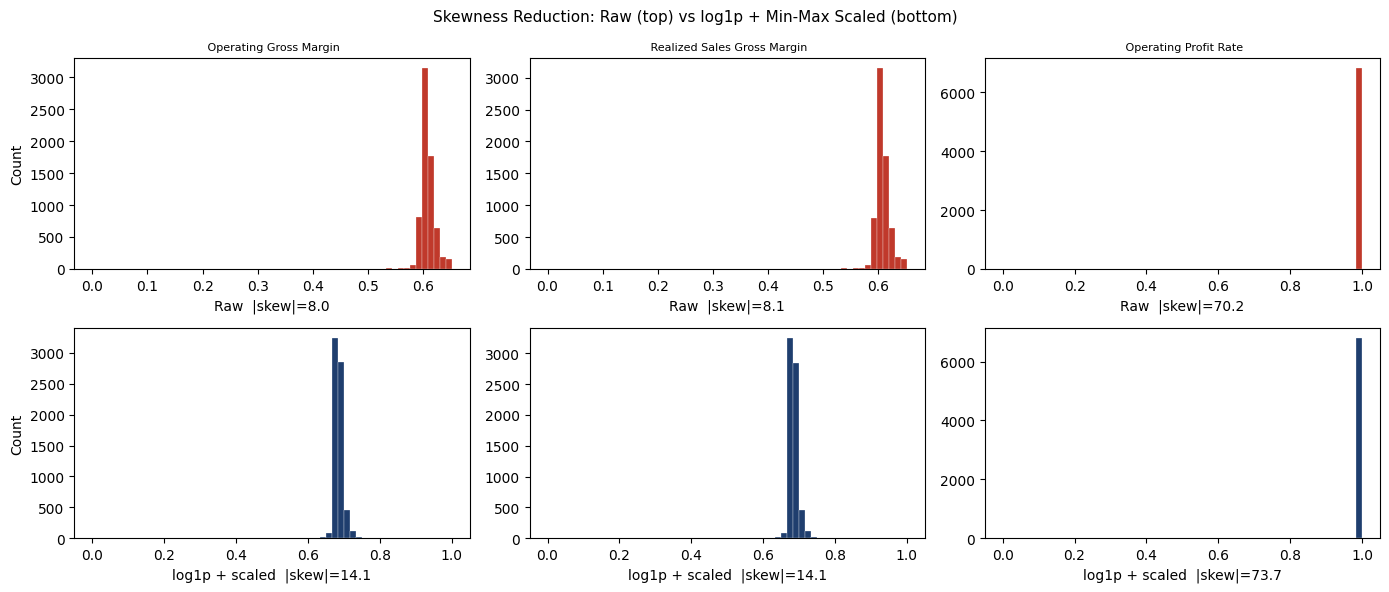

Scaled data shape: (6819, 97)
All feature ranges confirmed [0, 1]: True


In [ ]:
## ===============================================================
## Visualize Skewness Reduction (before vs after log1p)
## ===============================================================
## Pick 3 of the most skewed features and show side-by-side histograms.

demo_cols = skewed_cols[:3]
fig, axes = plt.subplots(2, len(demo_cols), figsize=(14, 6))

for col_i, col in enumerate(demo_cols):
    ## Before: raw values from df_clean
    axes[0, col_i].hist(df_clean[col].clip(upper=df_clean[col].quantile(0.99)),
                        bins=60, color='#c0392b', edgecolor='white', linewidth=0.2)
    axes[0, col_i].set_title(col[:28], fontsize=8)
    axes[0, col_i].set_ylabel('Count' if col_i == 0 else '')
    axes[0, col_i].set_xlabel(f'Raw  |skew|={skewness[col]:.1f}')

    ## After: log1p + scaled values from df_scaled
    axes[1, col_i].hist(df_scaled[col], bins=60,
                        color='#1f3e6e', edgecolor='white', linewidth=0.2)
    axes[1, col_i].set_ylabel('Count' if col_i == 0 else '')
    axes[1, col_i].set_xlabel(f'log1p + scaled  |skew|={skewness_after[col]:.1f}')

fig.suptitle('Skewness Reduction: Raw (top) vs log1p + Min-Max Scaled (bottom)', fontsize=11)
plt.tight_layout()
plt.show()

print('Scaled data shape:', df_scaled.shape)
print('All feature ranges confirmed [0, 1]:', 
      all(df_scaled[c].min() >= 0 and df_scaled[c].max() <= 1 for c in cols_to_scale))


## Final: Save Advanced-Cleaned (Scaled) Data

In [ ]:
## ===============================================================
## Save Scaled Data
## ===============================================================
print("\n" + "="*70)
print("SAVING FINAL CLEANED & SCALED DATA")
print("="*70)

df_scaled.to_csv(scaled_data_path, index=False)
print(f"\nScaled data saved to: {scaled_data_path}")
print(f"File size: {os.path.getsize(scaled_data_path) / 1e6:.2f} MB")

print(f"\nFinal dataset summary:")
print(f"  Rows: {df_scaled.shape[0]}")
print(f"  Columns: {df_scaled.shape[1]}")
print(f"  Features (scaled): {len(cols_to_scale)}")
print(f"  Metadata: is_outlier, noise_proxy, is_high_noise")
print(f"  Target: Bankrupt? (0=No, 1=Yes)")


SAVING FINAL CLEANED & SCALED DATA

Scaled data saved to: ./data/cleaned_data/scaled_data.csv
File size: 12.38 MB

Final dataset summary:
  Rows: 6819
  Columns: 97
  Features (scaled): 94
  Metadata: is_outlier, noise_proxy, is_high_noise
  Target: Bankrupt? (0=No, 1=Yes)


---

# Final Cleaning Summary and Future considerations

## What Was Done

### Core Phase (Steps 1–6)
- Confirmed zero NaN, infinite values, and duplicate rows
- Dropped constant-variance column: `Net Income Flag` (std = 0)
- Fixed column name typo: `Working capitcal` → `Working Capital`
- All 95 columns confirmed numeric with no character errors

### Advanced Phase
- **Skewness**: 62/94 features had |skewness| > 5 — applied `log1p` transformation before scaling
- **Outlier detection**: Gaussian Z-score with corrected |Z| > 5 threshold (28% flagged at |Z|>3 vs 11% at |Z|>5); flagged in `is_outlier` column
- **Heteroscedasticity**: Coefficient-of-variation proxy computed; high-noise observations flagged in `is_high_noise` column
- **Feature scaling**: Min-Max [0, 1] applied after log1p so the scaled range reflects the corrected distribution
- Saved production-ready CSV to `./data/cleaned_data/scaled_data.csv`

## Future considerations

1. Address 30:1 class imbalance with Tomek Links or SMOTE during training
2. Apply PCA or correlation-based pruning to the 28 collinear feature pairs identified above

---


## Data Cleaning Completion Status

### Cleaning Actions Summary

| Step | Action | Result |
|---|---|---|
| NaN check | `df.dropna()` | 0 rows removed — dataset had none |
| Infinite value check | `df.isin([inf, -inf])` | 0 cells — dataset had none |
| Duplicate check | `df.drop_duplicates()` | 0 rows removed — dataset had none |
| Constant column removal | Drop std=0 features | 1 column removed: `Net Income Flag` |
| Column name typo | Rename | `Working capitcal` → `Working Capital` |
| Data type correction | `pd.to_numeric(..., errors='coerce')` | All 95 columns confirmed numeric |
| Skewness reduction | `log1p` on features with \|skew\| > 5 | 62 features transformed |
| Outlier detection | Gaussian Z-score, \|Z\| > 5 | 763 rows flagged (11.2%) in `is_outlier` |
| Heteroscedasticity | Coefficient of variation per row | `noise_proxy` + `is_high_noise` added |
| Feature scaling | Min-Max [0, 1] after log1p | All 94 features scaled |

### Deliverables

| File | Rows | Columns | Use |
|---|---|---|---|
| `data/raw_data/data.csv` | 6,819 | 96 | Original — never modified |
| `data/cleaned_data/cleaned_data.csv` | 6,819 | 98 | EDA & interpretability |
| `data/cleaned_data/scaled_data.csv` | 6,819 | 98 | Production model training |